---
---

<table align="center" style="border-collapse: collapse; border: none; width: 100%;">
  <tr>
    <td style="border: none; width: 15%;">
      <img src="https://raw.githubusercontent.com/SouthPoleTelescope/spt_candl_data/main/logos/spt_logo.jpg" alt="SPT Logo" style="width: 100%; height: auto;">
    </td>
    <td style="border: none; text-align: center; vertical-align: middle; padding: 0 30px; width: 50%;">
      <span style="font-size: 4vw; font-weight: bold;">SPT-3G D1 BB</span>
    </td>
    <td style="border: none; width: 15%;">
      <img src="https://raw.githubusercontent.com/SouthPoleTelescope/spt_candl_data/main/logos/candl_logo.png" alt="CANDL Logo" style="width: 100%; height: auto;">
    </td>
  </tr>
</table>

---
---

This tutorial introduces you to working with the SPT-3G D1 BB data of [Zebrowski et al. 2025](https://arxiv.org/abs/2505.02827) in `candl`. `candl` is a python-based, differentiable CMB likelihood code designed to make analysis easier and more flexible.

__Overview:__

[Part I: Basics](#part1)

This part covers how to initialise the likelihood, access the band powers, understand the data model, and evaluate the likelihood.

[Part II: MCMC Analysis](#part2)

In this part we perform an MCMC analysis with Cobaya.

[PART III: Differentiable Techniques](#part3)

This part shows how to calculate derivatives of the likelihood.

__Resources:__
- [SPT candl data repository](https://github.com/SouthPoleTelescope/spt_candl_data)
- [SPT-3G D1 BB paper](https://arxiv.org/abs/2505.02827)
- [`candl` documentation](https://candl.readthedocs.io/en/latest/)
- [`candl` repository](https://github.com/Lbalkenhol/candl)
- [`candl` paper](https://arxiv.org/abs/2401.13433)

In [1]:
# Necessary imports and setup
%matplotlib inline

import numpy as np
import yaml
from copy import deepcopy

import candl
import candl.tools
import candl.interface
import candl.plots
import spt_candl_data

import matplotlib.pyplot as plt

candl.plots.set_plot_style()

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif"
})

---

<a id='part1'></a>

# PART I: Classical Analysis

This part teaches the basics of interacting with the SPT data through `candl`:

* Initialising the likelihood
* Evaluating the likelihood
* Plotting the band powers
* Working with transformations in the data model

<hr width="100%" style="border-style: none none dotted" color="#FFFFFF" size="6">

## Likelihood Initialisation

You can initialise the likelihood by simply pointing to the data set's `.yaml` file. If you have the `spt_candl_library` module installed you can use the shortcut `spt_candl_data.SPT3G_D1_BB`. The initialisation will produce some feedback that tells you what spectra are loaded, what will be done to model spectra before they are compared to the data, and any priors that are applied. There are different optional keywords you can supply to modify the likelihood at this stage (e.g. to remove internal priors or overwrite the data vector), check out the [`candl` documentation](https://candl.readthedocs.io/en/latest/) to learn more.

In [4]:
# Initialise the likelihood
candl_like = candl.Like(spt_candl_data.SPT3G_D1_BB)

Successfully initialised candl likelihood 'SPT-3G D1 BB (Zebrowski et al. 2025)' (type: <class 'candl.likelihood.Like'>).
Data loaded from '/opt/homebrew/Cellar/python@3.10/3.10.14/envs/jax_env/lib/python3.10/site-packages/spt_candl_data/SPT3G_D1_BB_v0/'.
Functional likelihood form: hamimeche_lewis
--------------------------------------------------------------------------------
It will analyse the following spectra:

BB 95x95     (5 bins, bin centres spanning ell = 77.8 - 440.6)
BB 95x150    (5 bins, bin centres spanning ell = 80.3 - 441.7)
BB 95x220    (5 bins, bin centres spanning ell = 78.8 - 440.6)
BB 150x150   (5 bins, bin centres spanning ell = 79.7 - 442.0)
BB 150x220   (5 bins, bin centres spanning ell = 78.4 - 442.3)
BB 220x220   (5 bins, bin centres spanning ell = 76.8 - 439.5)
--------------------------------------------------------------------------------
A data model consisting of 3 transformations has been initialised.
The following transformations will be applied to the 

## Evaluating the Likelihood

To evaluate the likelihood, supply a dictionary of CMB spectra and nuisance parameter values. The format expected is as follows:

`{'Dl': {'BB': ..., ...}, 'nuisance_par': ..., ...}`

CMB spectra are expected as Dls starting at `ell=2`, going up to the `.ell_max` of the likelihood. Below, we'll load a pre-calculated CMB spectrum from a file as well as a dictionary of all necessary parameter values. We will calculate our own predictions in the second part of this tutorial.

With the dictionary in the right format, we can call `.log_like()`. We will also calculate the `chi2` - note that this is not exactly `-2*candl_like.log_like()` as the `.log_like()` in ``candl`` function also applies some priors (as listed during initialisation). The first evaluations of these two functions are a little slow if you have JAX installed, as they are both jitted - but subsequent evaluations are much faster.

In [5]:
# Load a pre-calculated CMB spectrum and read in a dictionary of fiducial parameters
with open("../spt_candl_data/tests/SPT3G_D1_BB_test.yaml", "r") as f:
    test_dict = yaml.load(f, Loader=yaml.loader.SafeLoader)
test_spec = np.loadtxt(f"../spt_candl_data/tests/{test_dict['test_spectrum']}")
pars_for_like = deepcopy(test_dict["param_values"])
pars_for_like["Dl"] = {}
test_spec_save_order = ["ell", "TT", "TE", "EE", "BB", "pp", "kk"]
for i, spec in enumerate(test_spec_save_order):
    pars_for_like["Dl"][spec] = test_spec[:, i]

In [6]:
# Evaluate the likelihood
print(candl_like.log_like(pars_for_like))
print(candl_like.chi_square(pars_for_like))

-34.583742498047435
107.12369674659797


<hr width="100%" style="border-style: none none dotted" color="#FFFFFF" size="6">

## Data Access and Model Predictions

The SPT band powers are stored as a long vector with all measurements concatenated. The order is specified by the atrtibute `.spec_order` (which matches the output of the initialisation above). The following attributes are often useful:

* `.spec_order`: a list specifying the order of the spectra in the data vector
* `.data_bandpowers`: a long vector of band powers
* `.covariance`: the covariance matrix
* `.bins_start_ix`, `.bins_stop_ix`: lists that contain start and stop indices for the spectra
* `.N_bins`: a list containing the number of bins of each spectrum
* `.effective_ells`: the weighted bins centres of all all spectra

The code below uses these attributes to plot the band powers alongside model predictions, i.e. the sample CMB spectrum with the data model applied. The functions `.get_model_specs()` and `.bin_model_specs()` allow you to do this. We'll take a closer look at what the data model is after this.

In [7]:
# Transform CMB spectra and bin
model_spectrum = candl_like.get_model_specs(pars_for_like)# apply the data model
binned_model_spectrum = candl_like.bin_model_specs(model_spectrum)# bin into band powers

# Grab the error bars
error_bars = np.sqrt(np.diag(candl_like.covariance))

# We don't plot these, but this is how you calculate residuals
residuals = binned_model_spectrum - candl_like.data_bandpowers
relative_residuals = residuals / error_bars

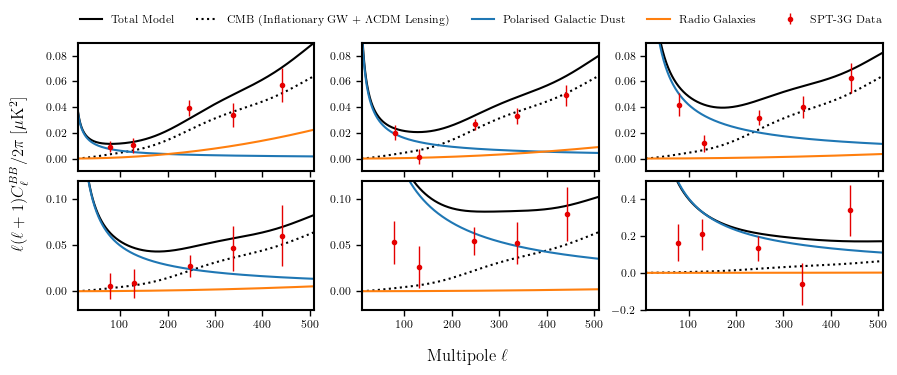

In [8]:
# We now create a plot similar to Fig 4 from Zebrowski et al. 2025
# Though here we are not showing the best-fit point and are summing the BB spectrum components together

plt.close()

fig, ax = plt.subplots(2, 3, sharex=True, sharey=False, figsize=(3 * 3.464, 1 * 3.464), gridspec_kw={"hspace": 0.075, "wspace": 0.2})

ix_for_spec = {"BB 95x95": (0,0),
               "BB 95x150": (0,1),
               "BB 95x220": (1,0),
               "BB 150x150": (0,2),
               "BB 150x220": (1,1),
               "BB 220x220": (1,2),
               }

lims_for_spec = {"BB 95x95": (-0.01, 0.09),
                "BB 95x150": (-0.01, 0.09),
                "BB 95x220": (-0.02,0.12),
                "BB 150x150": (-0.01, 0.09),
                "BB 150x220": (-0.02,0.12),
                "BB 220x220": (-0.2,0.5),
                }

# Get the foreground contributions
fg_dict = candl.tools.get_foreground_contributions(candl_like, pars_for_like, return_type="dict by spec", binning="unbinned")
fg_list = list(fg_dict["BB 95x95"].keys())

for i, spec in enumerate(candl_like.spec_order):

    # Plot full model
    ax[ix_for_spec[spec]].plot(candl_like.ells,
         model_spectrum[i*candl_like.N_ell_bins_theory:(i+1)*candl_like.N_ell_bins_theory],
         color="k",
         ls="-",
         label="Total Model")
    
    # Plot the LCDM theory
    ax[ix_for_spec[spec]].plot(pars_for_like["Dl"]["ell"],
         pars_for_like["Dl"]["BB"],
         color="k",
         ls=":",
         label="CMB (Inflationary GW + $\Lambda$CDM Lensing)")    

    # Plot the foreground contamination
    for fg in fg_list:
        ax[ix_for_spec[spec]].plot(candl_like.ells,
                                   fg_dict[spec][fg],
                                   label = fg)

    # Plot the data
    ells_to_plot = candl_like.effective_ells[candl_like.bins_start_ix[i]:candl_like.bins_stop_ix[i]]
    bdp_to_plot = candl_like.data_bandpowers[candl_like.bins_start_ix[i]:candl_like.bins_stop_ix[i]]
    err_to_plot = error_bars[candl_like.bins_start_ix[i]:candl_like.bins_stop_ix[i]]
    ax[ix_for_spec[spec]].errorbar(ells_to_plot,
                 bdp_to_plot,
                 yerr=err_to_plot,
                 lw=0,
                 marker="o",
                 ms=3,
                 elinewidth=1,
                 color="xkcd:red",
                 label="SPT-3G Data")
    
    # Finish plot for the panel
    ax[ix_for_spec[spec]].set_ylim(lims_for_spec[spec])

# Finish complete plot
ax[0,1].legend(ncol=5, loc="upper center", bbox_to_anchor=(0.5, 1.3), fontsize=8, frameon=False)
fig.supxlabel("Multipole $\ell$", y=-0.05)
fig.supylabel("$\ell(\ell+1)C_\ell^{BB}/2\pi\;[\mu\mathrm{K}^2]$", x=0.06)
ax[0,0].set_xlim((10, 510))

plt.show()


<hr width="100%" style="border-style: none none dotted" color="#FFFFFF" size="6">

## Data Structure and Data Model

To generate the predictions above, the likelihood adjusts the CMB spectra to make for a fair comparison to the data. The different transformations that are applied make up the data model. These are stored as objects in the `.data_model` list. The initialisation message at the start tells you what they are. Below we will grab one of them - the contamination due to radio galaxies - and interact with it. It requires the paramter `D500_95ghz_rg_poisson` in order to produce predictions. For details, see the [`candl` documentation](https://candl.readthedocs.io/en/latest/).

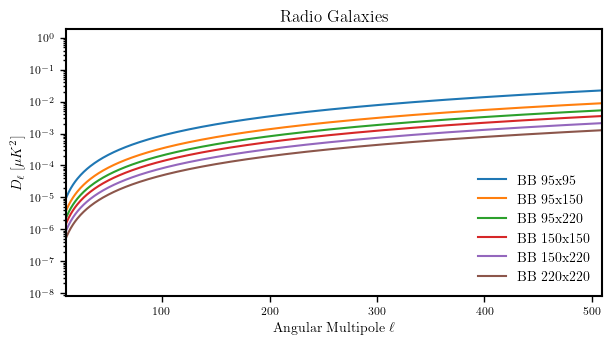

In [9]:
# Grab RG module
rg_module_ix = [transformation.descriptor for transformation in candl_like.data_model].index("Radio Galaxies")
rg_module = candl_like.data_model[rg_module_ix]

# Grab the parameter values from the prior
rg_amp_par = rg_module.param_names[0]
rg_params = {rg_amp_par:pars_for_like[rg_amp_par]}

# Calculate the expected EE dust contamination
rg_contamination = rg_module.output(rg_params)

# Plot
plt.close()

# Set figure size
fig = plt.gcf()
fig.set_size_inches(2 * 3.464, 1 * 3.464)

# Plot all EE contributions
for i, spec in enumerate(candl_like.spec_order):
    plt.plot(candl_like.ells, rg_contamination[i*candl_like.N_ell_bins_theory:(i+1)*candl_like.N_ell_bins_theory], label=spec)

plt.legend()

plt.title(rg_module.descriptor)
plt.ylabel("$D_\ell \; [\mu K^2]$")
plt.xlabel("Angular Multipole $\ell$")
plt.yscale("log")
plt.xlim((10, 510))

plt.show()


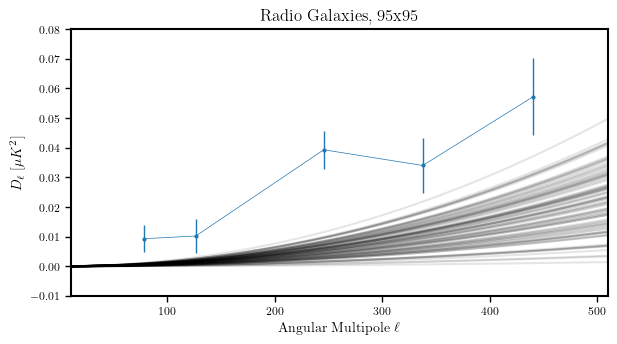

In [10]:
# Plot the dust contamination for a single spectrum, draw multiple realisations from the prior
spec_to_plot = "BB 95x95"
ix_of_spec = candl_like.spec_order.index(spec_to_plot)

# Plot
plt.close()

# Set figure size
fig = plt.gcf()
fig.set_size_inches(2 * 3.464, 1 * 3.464)

# Sample from some range
N_samples = 100
rg_sample_cov = np.atleast_2d(0.01**2)
rg_samples = np.tile(pars_for_like[rg_amp_par], (N_samples, 1)) + np.random.normal(0, 1, (N_samples, 1)) @ np.linalg.cholesky(rg_sample_cov).T

# Calculate CIB spectra and plot
for i in range(N_samples):
    if rg_samples[i] < 0:# disregard unphysical samples
        continue
    rg_contamination = rg_module.output({rg_amp_par:rg_samples[i]})
    plt.plot(candl_like.ells, rg_contamination[ix_of_spec*candl_like.N_ell_bins_theory:(ix_of_spec+1)*candl_like.N_ell_bins_theory], label=spec, alpha=0.1, color="k")


# Plot spectrum
plt.errorbar(candl_like.effective_ells[candl_like.bins_start_ix[ix_of_spec]:candl_like.bins_stop_ix[ix_of_spec]],
         candl_like.data_bandpowers[candl_like.bins_start_ix[ix_of_spec]:candl_like.bins_stop_ix[ix_of_spec]],
         yerr=np.sqrt(np.diag(candl_like.covariance)[candl_like.bins_start_ix[ix_of_spec]:candl_like.bins_stop_ix[ix_of_spec]]),
            lw=0.5,
            marker="o",
            ms=2,
            elinewidth=1)

# Finish plot
plt.title(rg_module.descriptor + ", " + "x".join(candl_like.spec_freqs[ix_of_spec]))
plt.ylabel("$D_\ell \; [\mu K^2]$")
plt.xlabel("Angular Multipole $\ell$")
#plt.yscale("log")
plt.xlim((10, 510))
plt.ylim((-0.01, 0.08))

plt.show()

---

<a id='part2'></a>

# PART II: MCMC Analysis with Cobaya

We now perform an MCMC analysis with [`Cobaya`](https://github.com/CobayaSampler/cobaya). We forego using Boltzmann solvers and instead use scaled templates for the prediction of the BB power spectrum.


In [11]:
from cobaya import run
from getdist.mcsamples import MCSamplesFromCobaya
from getdist import plots

In [12]:
cobaya_info_opt = {}

# Likelihood
cobaya_info_opt["likelihood"] = candl.interface.get_cobaya_info_dict_for_like(candl.Like(spt_candl_data.SPT3G_D1_BB,
                                                                                         feedback=False),
                                                                              clear_internal_priors=False)

# Parameters to be sampled
cobaya_info_opt["params"] = {
        'r':
           {'latex': 'r',
            'prior': {'max': 4, 'min': 0},
            'ref': .02,
            'proposal': 0.05},
        'Alens':
           {'latex': 'A_L',
            'prior': {'max': 10, 'min': 0},
            'ref': 1.0,
            'proposal': 0.05},
        'D500_95ghz_rg_poisson':
           {'latex': 'D^{rg,\,95\,\mathrm{GHz}}_{\ell=500}',
            'prior': {'max': 0.2, 'min': 0},
            'ref': .02,
            'proposal': 0.001},
        'D80_150ghz': {'latex': 'A_{\ell=80}^{150\,\mathrm{GHz}}',
            'prior': {'max': 1, 'min': 0},
            'ref': .05,
            'proposal': 0.01},
        'alpha_candl': {'latex': '\alpha',
            'prior': {'max': -0.2-2, 'min': -1.2-2},
            'ref': -0.8-2,
            'proposal': 0.1},
        'beta_gal': {'latex': '\beta',
            'prior': {'max': 3, 'min': 0},
            'ref': 1.6,
            'proposal': 0.1},
        'pcal95':{'latex': 'Pcal_{95}',
            'prior': {'max': 2, 'min': 0.5},
            'ref': 1.0,
            'proposal': 0.005},
        'pcal150':{'latex': 'Pcal_{150}',
            'prior': {'max': 2, 'min': 0.5},
            'ref': 1.0,
            'proposal': 0.005},
        'pcal220':{'latex': 'Pcal_{220}',
            'prior': {'max': 2, 'min': 0.5},
            'ref': 1.0,
            'proposal': 0.005},
}

# Sampler
cobaya_info_opt["sampler"] = {'mcmc': {
                      'drag': False,
                       'Rminus1_cl_stop': 0.001,
                      'oversample_power': 0.5,
                      'proposal_scale': 2.0,
                      'max_samples': 10000}}


# Theory templates
t_path = "../spt_candl_data/foreground_templates/"
cobaya_info_opt["theory"] = {"BB templates":
                             {'external': candl.interface.CobayaTheoryBBTemplate,
                              'template_filenames':
                              {'lensing_B_modes': t_path + "dl_lensedBB.txt",
                               'r': t_path + "dl_r_long.txt"},
                               'ix_in_file': {'ell': 0, 'BB': 1},
                               'A_L_par_name': "Alens",  # name of the lensing amplitude parameter
                               'r_par_name': "r"}}

In [13]:
# We now run Cobaya's Metropolis-Hastings sampler for 10000 samples - since we don't need to evaluate a Boltzmann solver this is fast (~5sec)
updated_info, sampler = run(cobaya_info_opt)

gd_samples = MCSamplesFromCobaya(updated_info, sampler.products()["sample"])
all_chains = sampler.products()["sample"]

Successfully initialised candl likelihood 'SPT-3G D1 BB (Zebrowski et al. 2025)' (type: <class 'candl.likelihood.Like'>).
Data loaded from '/opt/homebrew/Cellar/python@3.10/3.10.14/envs/jax_env/lib/python3.10/site-packages/spt_candl_data/SPT3G_D1_BB_v0/'.
Functional likelihood form: hamimeche_lewis
--------------------------------------------------------------------------------
It will analyse the following spectra:

BB 95x95     (5 bins, bin centres spanning ell = 77.8 - 440.6)
BB 95x150    (5 bins, bin centres spanning ell = 80.3 - 441.7)
BB 95x220    (5 bins, bin centres spanning ell = 78.8 - 440.6)
BB 150x150   (5 bins, bin centres spanning ell = 79.7 - 442.0)
BB 150x220   (5 bins, bin centres spanning ell = 78.4 - 442.3)
BB 220x220   (5 bins, bin centres spanning ell = 76.8 - 439.5)
--------------------------------------------------------------------------------
A data model consisting of 3 transformations has been initialised.
The following transformations will be applied to the 

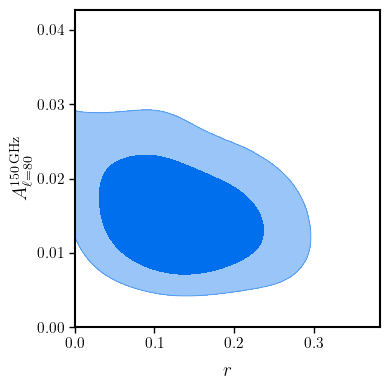

In [14]:
# Let's look at r and the dust contamination - recreating Fig. 6 of Zebrowski et al. 2025
# Note differences to the paper plot are due to the convergence of the chains - for a full analysis you want to run the above analysis for longer

plt.close()

g = plots.get_subplot_plotter(width_inch=4)
g.plots_2d(gd_samples, ["r", "D80_150ghz"],
           filled=True)

plt.show()

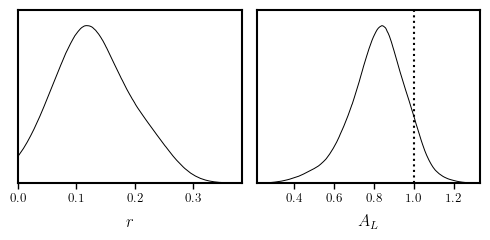

In [15]:
# We can also look at the 1d marginalised posteriors
# Compare the left panel to Fig. 5 in Zebrowski et al. 2025

plt.close()

g = plots.get_subplot_plotter(width_inch=5)
g.plots_1d(gd_samples, ["r", "Alens"], nx=2)

g.subplots[0,1].axvline(1, color="k", ls=":")

plt.show()

---

<a id='part3'></a>

# PART III: Differentiable Techniques

The SPT-3G D1 BB likelihood - like all `candl` likelihoods - is differentiable. We can use this to estimate the constraining power on r. Note that for gradients we rely on JAX and for a fully differentiable pipeline we need a differentiable theory code - since we are dealing with simple scaled templates here this is trivial.

In [16]:
import jax

In [17]:
# Grab the theory calculator
template_path = "../spt_candl_data/foreground_templates/"
theory = candl.interface.CobayaTheoryBBTemplate({"template_filenames":
                                        {'lensing_B_modes': template_path + "dl_lensedBB.txt",
                                         'r': template_path + "dl_r_long.txt"},
                                         'ix_in_file': {'ell': 0, 'BB': 1},
                                         'A_L_par_name': 'Alens'})

In [18]:
# Grab the best-fit sample
mrg_dict = gd_samples.getMargeStats()
fid_pars = {p: mrg_dict.parWithName(p).bestfit_sample for p in list(cobaya_info_opt["params"].keys())}
pars_for_theory_code = {"params": fid_pars}

# Define a function that moves from a dictionary of parameter values to the log likelihood
def pars_to_logl(pars):
    theory.calculate(pars)
    dict_for_like = pars["params"]
    dict_for_like["Dl"] = pars["Dl"]
    logl = candl_like.log_like(dict_for_like)

    # cleanup
    del pars["Dl"]
    del pars["params"]["Dl"]
    del pars["Cl"]
    
    return logl

In [19]:
# Calculate the Hessian, juggle into an array
hess_dict = jax.hessian(pars_to_logl)(pars_for_theory_code)
par_order = list(fid_pars.keys())
hess_arr = np.array([[hess_dict["params"][i]["params"][j] for i in par_order] for j in par_order])

# Get approximate error bars (based on the Fisher matrix)
fisher_mat = np.linalg.inv(-hess_arr)
sigma_r = np.sqrt(fisher_mat[0,0])

In [20]:
# This does not quite match the σ(r) quoted in Z25, but bear in mind that this not the same definition and depends on the exact point where we evaluate the Hessian
# Still, it should be within ~10%
print(f"σ(r) ~ {np.round(sigma_r, 3)}")

σ(r) ~ 0.064
